# 03 — Feature Engineering

This notebook builds the feature engineering story. It loads the precomputed
feature matrices from `results/features/`, inspects distributions, explores
class imbalance, and documents the final feature set decision.

**Prerequisite:** Run `c2detect features` before this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from botnet_c2.data.registry import SCENARIOS
from botnet_c2.features.engineering import (
    LEAKAGE_COLUMNS,
    get_feature_columns,
)

RESULTS_DIR = Path("../results")
FEATURES_DIR = RESULTS_DIR / "features"
FEATURE_COLS = get_feature_columns()

## 1. Feature Matrix Sample

Load neris_42 and inspect the shape, index, and dtypes of the feature matrix.

In [2]:
neris42 = pd.read_parquet(FEATURES_DIR / "neris_42_features.parquet")

print(f"Shape:   {neris42.shape}")
print(f"Columns: {list(neris42.columns)}")
print(f"\nFeature columns: {FEATURE_COLS}")
print(f"Leakage columns (excluded from model): {LEAKAGE_COLUMNS}")
print()
neris42.dtypes

Shape:   (1354524, 16)
Columns: ['time_bin', 'ip', 'scenario_id', 'degree', 'in_degree', 'out_degree', 'kcore', 'pagerank', 'betweenness', 'flow_count', 'window_node_count', 'in_degree_norm', 'flow_count_norm', 'delta_degree', 'is_bot', 'family']

Feature columns: ['degree', 'in_degree', 'in_degree_norm', 'out_degree', 'kcore', 'pagerank', 'betweenness', 'flow_count', 'flow_count_norm', 'delta_degree']
Leakage columns (excluded from model): ['window_bot_fraction']



time_bin             datetime64[us, UTC]
ip                                   str
scenario_id                          str
degree                             int64
in_degree                          int64
out_degree                         int64
kcore                              int64
pagerank                         float64
betweenness                      float64
flow_count                         int64
window_node_count                  int64
in_degree_norm                   float64
flow_count_norm                  float64
delta_degree                       int64
is_bot                              bool
family                               str
dtype: object

In [3]:
neris42.head(5)

,time_bin,ip,scenario_id,degree,in_degree,out_degree,kcore,pagerank,betweenness,flow_count,window_node_count,in_degree_norm,flow_count_norm,delta_degree,is_bot,family
0,2011-08-10 09:45:00+00:00,0.0.0.0,neris_42,1,0,1,1,0.000023,0.0,1,19441,0.0,0.000051,0,False,Neris
1,2011-08-10 09:45:00+00:00,00:15:17:2c:e5:2d,neris_42,1,0,1,1,0.000023,0.0,1,19441,0.0,0.000051,0,False,Neris
2,2011-08-10 09:45:00+00:00,1.144.156.226,neris_42,1,0,1,1,0.000023,0.0,1,19441,0.0,0.000051,0,False,Neris
3,2011-08-10 09:45:00+00:00,1.144.5.55,neris_42,1,0,1,1,0.000023,0.0,1,19441,0.0,0.000051,0,False,Neris
4,2011-08-10 09:45:00+00:00,1.148.38.207,neris_42,1,0,1,1,0.000023,0.0,1,19441,0.0,0.000051,0,False,Neris


In [4]:
# Summary statistics split by is_bot
neris42.groupby("is_bot")[FEATURE_COLS].describe().T

is_bot                     False         True 
degree       count  1.341567e+06  12957.000000
             mean   2.038126e+00      2.736976
             std    1.163818e+02     17.368328
             min    0.000000e+00      1.000000
             25%    1.000000e+00      1.000000
...                          ...           ...
delta_degree min   -3.153000e+03   -385.000000
             25%    0.000000e+00      0.000000
             50%    0.000000e+00      0.000000
             75%    0.000000e+00      0.000000
             max    6.618000e+03    324.000000

[80 rows x 2 columns]

## 2. Feature Distributions

Violin plots for each feature, split by `is_bot`. Bot IPs should show
higher values for degree, in_degree, kcore, and flow_count — consistent
with the hub-and-spoke topology identified in notebook 02.

In [5]:
# Load all scenarios for distribution plots
all_dfs = []
for sid in SCENARIOS:
    path = FEATURES_DIR / f"{sid}_features.parquet"
    if path.exists():
        df = pd.read_parquet(path)
        df["scenario_id"] = sid
        all_dfs.append(df)

all_features = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows: {len(all_features):,}")
print(
    f"Bot rows:   {all_features['is_bot'].sum():,} ({100 * all_features['is_bot'].mean():.2f}%)"
)

Total rows: 7,545,898
Bot rows:   108,033 (1.43%)


C:\Users\ssarv\botnet-graph-analysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\ssarv\botnet-graph-analysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


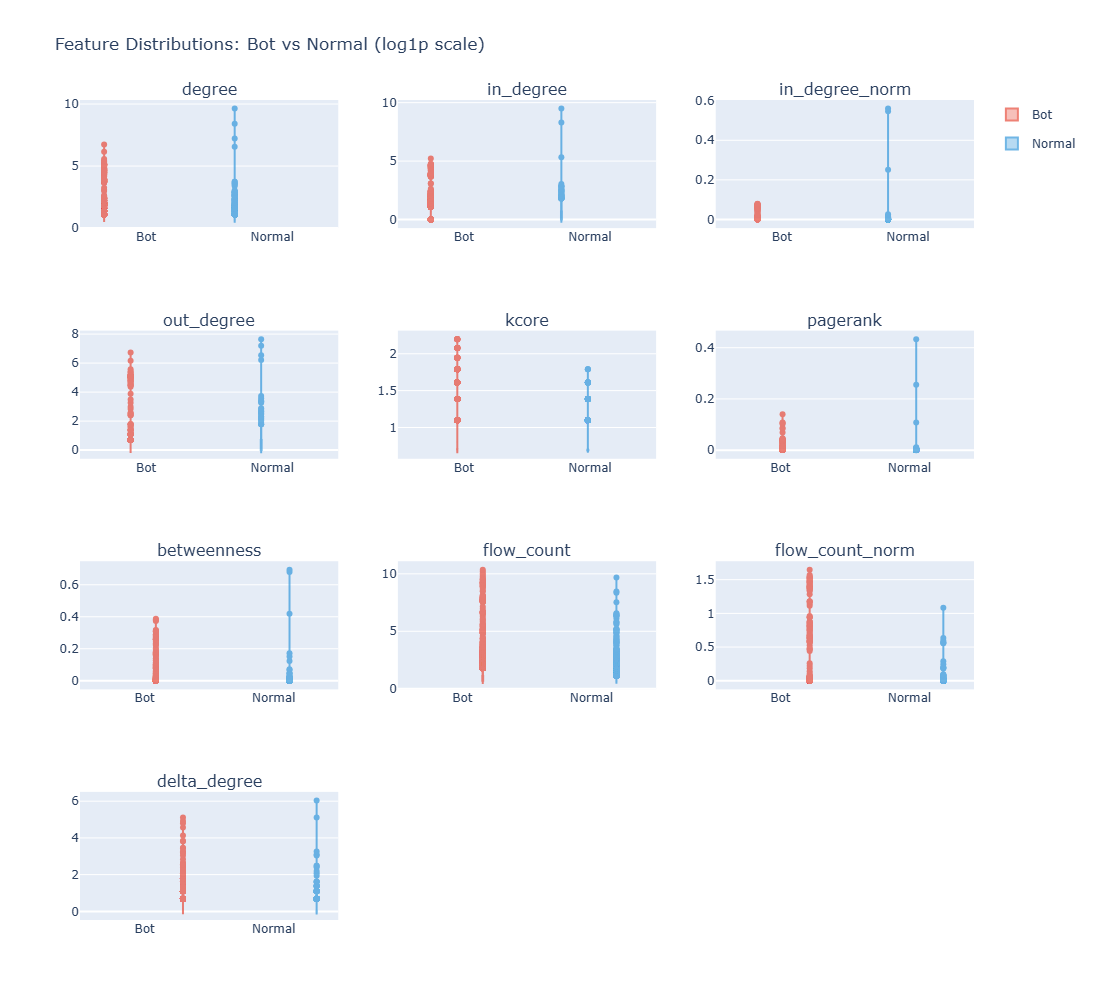

In [6]:
# Sample for plotting (full dataset is too large for violin plots)
sample_bot = all_features[all_features["is_bot"]].sample(
    min(5000, all_features["is_bot"].sum()), random_state=42
)
sample_normal = all_features[~all_features["is_bot"]].sample(5000, random_state=42)
sample = pd.concat([sample_bot, sample_normal])
sample["label"] = sample["is_bot"].map({True: "Bot", False: "Normal"})

fig = make_subplots(
    rows=4,
    cols=3,
    subplot_titles=FEATURE_COLS,
)

colors = {"Bot": "#e74c3c", "Normal": "#3498db"}

for idx, col in enumerate(FEATURE_COLS):
    row = idx // 3 + 1
    col_pos = idx % 3 + 1
    for label, grp in sample.groupby("label"):
        fig.add_trace(
            go.Violin(
                y=np.log1p(grp[col]),
                name=label,
                legendgroup=label,
                showlegend=(idx == 0),
                line_color=colors[label],
                box_visible=True,
                meanline_visible=True,
                opacity=0.7,
            ),
            row=row,
            col=col_pos,
        )

fig.update_layout(
    title="Feature Distributions: Bot vs Normal (log1p scale)",
    height=1000,
    violinmode="group",
)
fig.show()

## 3. Correlation Heatmap

Identify collinearity in the feature set. Highly correlated features provide
redundant signal — LightGBM handles this gracefully, but it is useful to
know which features carry independent information.

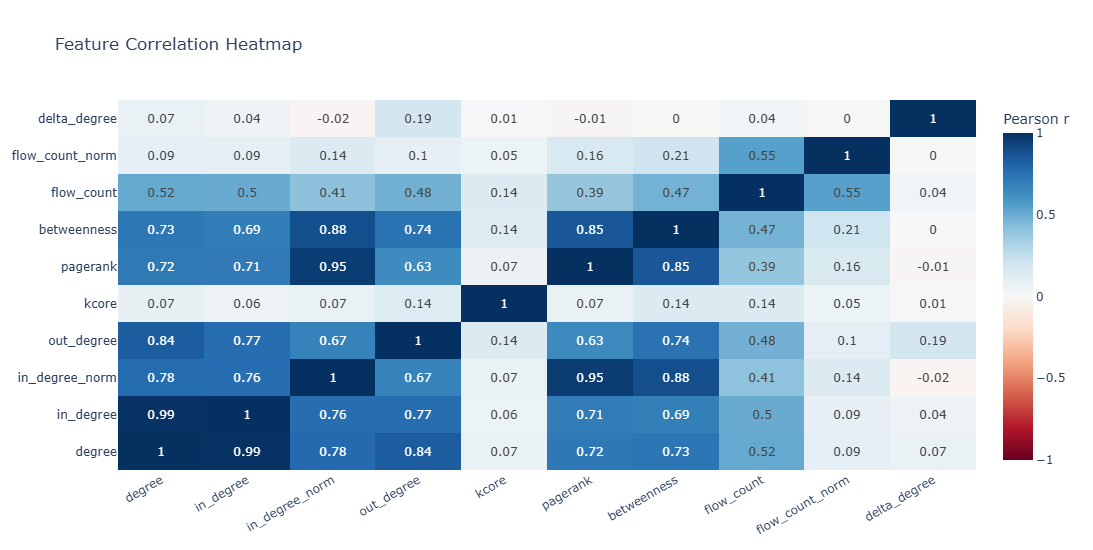

In [7]:
corr = all_features[FEATURE_COLS].corr()

fig = go.Figure(
    go.Heatmap(
        z=corr.values,
        x=FEATURE_COLS,
        y=FEATURE_COLS,
        colorscale="RdBu",
        zmid=0,
        colorbar={"title": "Pearson r"},
        text=corr.round(2).values,
        texttemplate="%{text}",
    )
)
fig.update_layout(
    title="Feature Correlation Heatmap",
    height=550,
    xaxis_tickangle=-30,
)
fig.show()

## 4. Class Imbalance

Bot IPs as a fraction of all active IPs per scenario. The severe imbalance
(0.1% - 4.7%) is the primary reason PR-AUC is used as the evaluation metric
rather than accuracy or ROC-AUC.

In [8]:
imbalance = (
    all_features.groupby(["scenario_id", "family"])["is_bot"]
    .agg(n_total="count", n_bot="sum")
    .assign(bot_fraction=lambda x: x["n_bot"] / x["n_total"])
    .reset_index()
    .sort_values("bot_fraction", ascending=False)
)

print("Class imbalance per scenario:")
print(imbalance.to_string(index=False))

print(
    f"\nRandom PR-AUC baseline (class prevalence): {imbalance['bot_fraction'].mean():.3f}"
)

Class imbalance per scenario:
scenario_id family  n_total  n_bot  bot_fraction
   neris_50  Neris   805981  37532      0.046567
    rbot_44   Rbot  1356371  28502      0.021013
  donbot_47 Donbot   174560   2865      0.016413
    nsis_53   Nsis   123324   1921      0.015577
   virut_54  Virut   843040   8667      0.010281
   neris_42  Neris  1354524  12957      0.009566
   neris_43  Neris   866475   6358      0.007338
   murlo_49  Murlo  1103683   6315      0.005722
   virut_46  Virut    48606    260      0.005349
    rbot_45   Rbot   361922   1236      0.003415
    rbot_51   Rbot   417088   1345      0.003225
   sogou_48  Sogou    43711     38      0.000869
    rbot_52   Rbot    46613     37      0.000794

Random PR-AUC baseline (class prevalence): 0.011


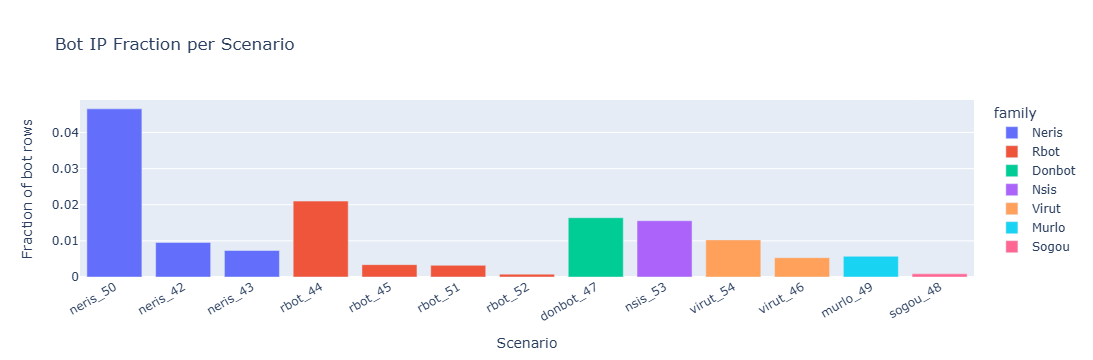

In [9]:
fig = px.bar(
    imbalance,
    x="scenario_id",
    y="bot_fraction",
    color="family",
    title="Bot IP Fraction per Scenario",
    labels={"bot_fraction": "Fraction of bot rows", "scenario_id": "Scenario"},
)
fig.update_xaxes(tickangle=-30)
fig.show()

## 5. Delta Degree

Time series of `delta_degree` for one C2 IP vs. one normal IP in neris_42.
The delta feature captures temporal dynamics: a C2 node that suddenly receives
many new bot connections in a window will have a large positive spike.

C2 candidate IP:     147.32.84.229
Normal candidate IP: 188.205.231.61


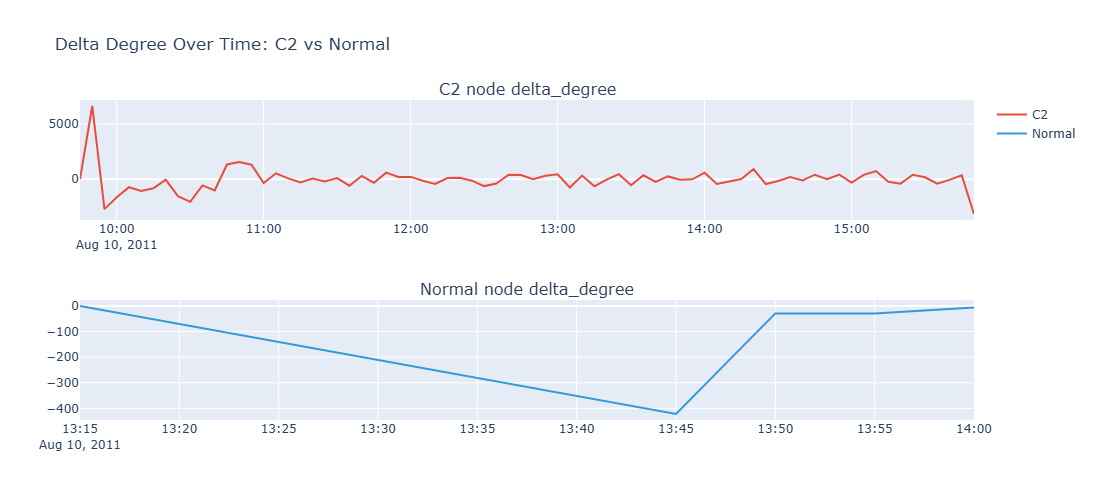

In [10]:
# Find the highest in-degree IP (likely C2) in neris_42
c2_candidate = neris42.groupby("ip")["in_degree"].max().idxmax()
normal_candidate = (
    neris42[~neris42["is_bot"]]
    .groupby("ip")["flow_count"]
    .mean()
    .sort_values(ascending=False)
    .index[5]  # 6th most active normal IP
)

print(f"C2 candidate IP:     {c2_candidate}")
print(f"Normal candidate IP: {normal_candidate}")

c2_ts = neris42[neris42["ip"] == c2_candidate].sort_values("time_bin")
normal_ts = neris42[neris42["ip"] == normal_candidate].sort_values("time_bin")

fig = make_subplots(
    rows=2, cols=1, subplot_titles=["C2 node delta_degree", "Normal node delta_degree"]
)
fig.add_trace(
    go.Scatter(
        x=c2_ts["time_bin"],
        y=c2_ts["delta_degree"],
        mode="lines",
        name="C2",
        line={"color": "#e74c3c"},
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=normal_ts["time_bin"],
        y=normal_ts["delta_degree"],
        mode="lines",
        name="Normal",
        line={"color": "#3498db"},
    ),
    row=2,
    col=1,
)
fig.update_layout(title="Delta Degree Over Time: C2 vs Normal", height=500)
fig.show()

## 6. Feature Set Decision

| Feature | Justification | Note |
|---------|--------------|------|
| `degree` | Total connectivity — C2 hubs are highly connected | Undirected |
| `in_degree` | Receives from many infected hosts | Strongest C2 signal |
| `out_degree` | Controller issues commands to all bots | Directed |
| `kcore` | Dense subgraph membership — C2 in the core | Undirected |
| `pagerank` | Influence in directed graph — C2 receives flows from many | Directed |
| `betweenness` | Bridge nodes in communication path | Approximated for large windows |
| `flow_count` | Communication intensity proxy | Replaces clustering (which is 0 by construction) |
| `delta_degree` | Temporal anomaly detection | Post-hoc, per IP across bins |
| `window_node_count` | Guards against small-window artifacts | Context feature |

**Excluded:** `local_clustering` (zero for all hub-and-spoke graphs — confirmed in notebook 02),
`window_bot_fraction` (target leakage — defined in LEAKAGE_COLUMNS).